# Intro

**Problem**- I get the following error when I run my simulations: `LibraryError: The simulation model supplied resulted in a parent node having a time value <= to its child. This can occur either as a result of multiple bottlenecks happening at the same time or because of numerical imprecision with very small population sizes.`  

The simulation steps are as follows:
1. convert species distribution model predictions to a local deme size matrix (the input matrix has values ranging from 0-1 and the output is all positive integers or zero).
2. create a 2D stepping stone model (msprime Demography object) by converting the local deme size matrix to a metapopulation connected by a constant migration rate
3. add discrete population size changes to the original 2D stepping stone model according to time-specific local deme size matrices
4. merge all of the demes in the metapopulation into a single population at a specific time point in the past
5. select two individuals from each deme that has at least two individuals in the most recent time step and run coalescent simulations with msprime.sim_ancestry().

I think the error is due to numerical imprecision with very small population sizes (some populations go extinct often or remain at low or zero population size the entire simulation) because it happens randomly across input parameter combinations- some simulations are successful and some fail. The only assuredly successful simulations occurred when I used a single 2D stepping stone landscape that then coalesced into a single panmictic population. The parameters that I examined were:
- number of landscapes/time steps: 1, 3, 5, 10
- size of the ancestral population: 5000, 50000, 500000
- recombination rate: 0, 1e-9
I used a constant migration rate (0.0001 forward, scaled backward) and maximum local deme size (100).  

Based on my exploration, it seems like the probability of failure increases with the number of demes that are simulated- simulations with the full number of demes (117 x 110) fail more frequently than those run with fewer demes, e.g. 9/18 simulations failed with the full number of demes, while 3/200 simulations failed with a 10 x 10 matrix. 

This notebook is separated into three sections: the functions I use for the simulations (**Functions**) and the minimum reproducible example (**Minimum reproducible example**), which takes ~4 seconds to run with 200 simulations. 


# Functions
These are the functions I'm using to conduct simulations and are relevant to the present error. Load these before running the minimum reproducible example.

- `stepping_stone2d()`- convert a local deme size matrix and migration rate (single value or matrix) into an msprime Demography object
- `add_landscape_change()`- add discrete population size changes to the original 2D stepping stone model according to species distribution models projected to time periods in the past
- `add_nonspatial_phase()`- collapse the metapopulation into a single population at a certain time point in the past


## Migration matrix from deme sizes
This is a skeleton to facilitate creating a migration matrix from a matrix of deme sizes.  
The formula for scaling the migration rates, which is always recommended is:  
mig donor -> recipient = (recipient size / donor size) * rate  
(we're thinking backward in time)  

In `migration_matrix()`, migration can occur in four directions from the focal deme unless they are at the edge of the matrix. In `migration_matrix_diagonal()`, diagonal migration is also allowed. I'm not sure if I want to allow diagonal in the final implementation, but keeping it here for posterity.

In [2]:
import numpy as np

def migration_matrix(populations, rate, scale=True):
    d = populations.shape[0] * populations.shape[1]
    M = np.zeros((d, d))
    
    for i in range(populations.shape[0]):
        for j in range(populations.shape[1]):
            current_index = i * populations.shape[1] + j
            # check the neighboring populations and calculate the migration rates. Looping through tuples was a neat trick! Saved a lot of time.
            for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                # check for edges
                if 0 <= i + di < populations.shape[0] and 0 <= j + dj < populations.shape[1]:
                    neighbor_index = (i + di) * populations.shape[1] + (j + dj)
                    if scale:
                        # mig = donor / recipient * rate unless the pop size is zero
                        M[current_index, neighbor_index] = populations[i + di, j + dj] / populations[i, j] * rate if populations[i, j] != 0 else 0
                    else:
                        M[current_index, neighbor_index] = rate


    return M


## 2D Stepping Stone model

Now to write a basic function! This will read in a single raster and create an msprime demography object with that single raster. I updated the function to use the `migration_matrix()` function, which is faster than the original implementation.  
`initial_size` is the local population size for each deme in the model  
`rate` is the migration rate between populations. Can be a single numerical value or a matrix that corresponds to all migration edges in the model.  
`scale` is a logical, determining if the migration rates should be scaled by the donor and recipient population sizes (True) or not. True is the default, since this is recommended behavior.


In [3]:
import msprime
import numpy as np

def stepping_stone2d(initial_size, rate, scale=True):
    assert len(initial_size.shape) <= 3

    n, m = initial_size.shape
    N = n * m
    model = msprime.Demography.isolated_model(initial_size.reshape(N))

    # set population names
    for j in range(n):
        for k in range(m):
            index = j * m + k
            model.populations[index].name = f"pop_{j}_{k}"

    if np.array(rate).ndim == 0:
        if scale:
            model.migration_matrix = migration_matrix(initial_size, rate, scale=True)
        else: 
            model.migration_matrix = migration_matrix(initial_size, rate, scale=False)
    else:
        assert rate.shape == (N, N), f"Expected a migration matrix with the shape {(N, N)} and instead got {rate.shape}"
        model.migration_matrix = rate

    
    return model

## Demographic changes based on landscape change to 2D stepping stone model

The `model` is an `msprime.Demography` object that needs to be initialized using `stepping_stone_2d()`.  
`k_stack` is a 3D numpy array of the local carrying capacities across the landscape for each timestep except the most current timestep.  
`timestep` is the amount of time that passes between each landscape change, measured in generations. For instance, if each landscape is 100 years apart and the generation time of the organism is 1 year, `timestep` is 100. However, if the generation time of the organism is 2 years, `timestep` is 50. 


In [4]:
import msprime
import numpy as np
def add_landscape_change(model, k_stack, timestep = 1, rate = 0.001, scale=True):
    # iterate through the first dimension of a 3D array, where the array represents different time steps of population size change
    for step in range(1, k_stack.shape[0]):
        # get the population size values of the current array
        kmat = k_stack[step]

        # get the population size values of array from the previous time step
        kmat_prev = k_stack[step - 1]

        # get the shape of the array
        n, m = kmat.shape

        ##### Update population sizes #####
        # add population size changes according to the values of the current array
        for j in range(n):
            for k in range(m):
                # only update the population size if it is different from the previous time point
                if kmat[j, k] != kmat_prev[j, k]:
                    # add a demographic change to each cell in the raster
                    model.add_population_parameters_change(time=step * timestep, population=f"pop_{j}_{k}", initial_size=kmat[j, k])

        ##### Update migration rates #####

        # add migration rate change for each time step
        # ## iterate through the population sizes
        for i in range(n):
            for j in range(m):
                ## also index the neighboring cells
                for di, dj in [(-1, 0), (1, 0), (0, -1), (0, 1)]:
                    ## check for edges
                    if 0 <= i + di < kmat.shape[0] and 0 <= j + dj < kmat.shape[1]:
                        ## only update migration if the donor and recipient population sizes are different between time points
                        if kmat[i + di, j + dj] != kmat_prev[i + di, j +dj] and kmat[i, j] != kmat_prev[i, j]:
                            if scale:
                                ## mig = donor / recipient * rate unless the pop size is zero
                                r = kmat[i + di, j + dj] / kmat[i, j] * rate if kmat[i, j] != 0 else 0
                                model.add_migration_rate_change(time = step * timestep, rate = r, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                            else:
                                model.add_migration_rate_change(time = step * timestep, rate = rate, source=f"pop_{i}_{j}", dest=f"pop_{i + di}_{j + dj}")
                    
                            
                
    
    return model


## Add nonspatial phase to 2D stepping stone model

The `split_array()` function splits any 1D array into equal-sized chunks, but makes sure the chunk size is never less than 2. If the chunk is less than 2, the chunk is merged with the chunk before it. 

`ancestral_size` is the size of the ancestral population that all demes coalesce to. 

`merge_time` is the time in generations that the metapopulation merges into the ancestral population(s)

In [5]:
import msprime
import numpy as np

def add_nonspatial_phase(model, ancestral_size, merge_time):
    # add an ancestral population
    model.add_population(name = "ANC", initial_size=ancestral_size)

    # get names of populations for initiating the collecting phase
    pop_names = [[pop.name] for pop in model.populations if pop.name != "ANC"]
    
    # add the time when the spatial simulation collapses into the collecting phase
    [model.add_population_split(time = merge_time, derived = name, ancestral = "ANC") for name in pop_names]

    return model

## Minimum reproducible example

In [6]:
# function to run the simulation
def sim(k, num_layers, ancestral_ne, recomb_rate):
    m = stepping_stone2d(k[0], rate = 0.001)

    m = add_landscape_change(model = m, k_stack = k[0:num_layers], timestep = 1000)

    m = add_nonspatial_phase(m, ancestral_size=ancestral_ne, merge_time=num_layers * 1000 + 1000)

    m.sort_events()

    # get populations with at least two individuals to sample for coalescent simulations
    nzp = []
    for i in range(len(m.populations)):
        if m.populations[i].initial_size >= 2.0 and m.populations[i].name != "ANC":
            nzp.append(m.populations[i].name)

    pop_dict = {key: 2 for key in nzp}

    ts = msprime.sim_ancestry(pop_dict, sequence_length=1e6, demography = m, recombination_rate=recomb_rate, record_provenance=False)

    return f"num_layers = {num_layers}, ancestral_ne = {ancestral_ne}, recomb_rate = {recomb_rate}, success = Yes\n"



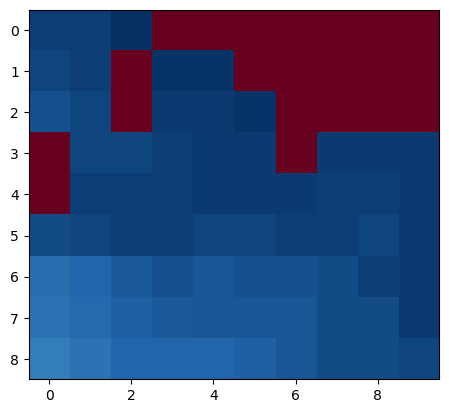

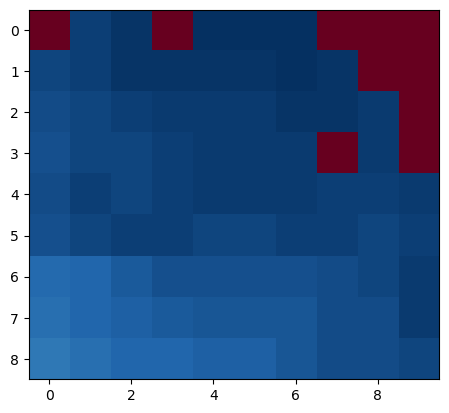

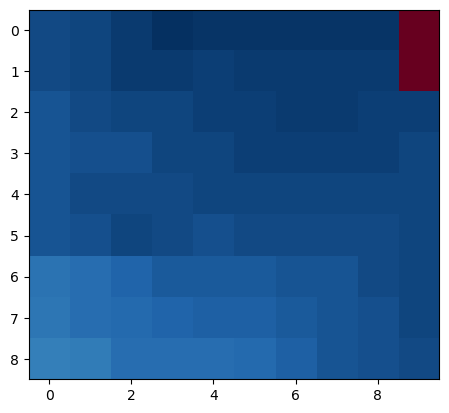

In [10]:
# read K array. replace with the path to the file on your machine
kpath = "/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/kmat.npy"

k = np.load(kpath)

from matplotlib import pyplot

pyplot.imshow(k[0], cmap='RdBu')
pyplot.show() 
pyplot.imshow(k[1], cmap='RdBu')
pyplot.show() 
pyplot.imshow(k[2], cmap='RdBu')
pyplot.show() 


In [ ]:
# replace this path to somewhere on your computer to house the debugger output
outfile = '/Users/connorfrench/Dropbox/Old_Mac/software-dev/spaceprime/debug_2dss_github.txt'

for nl in [3] * 200:
    try:
        success = sim(k = k, num_layers = nl, ancestral_ne = 50000, recomb_rate = 0)
        with open(outfile, 'a') as f:
            f.write(success)
    except Exception as e:
        er = str(e)
        failure = f"num_layers = {nl}, ancestral_ne = 50000, recomb_rate = 0, success = No, error = {er}\n"
        with open(outfile, 'a') as f:
            f.write(failure)